# Nestedness Visualization - Advanced Node Filtering Strategies

This notebook implements different filtering strategies to better visualize nestedness patterns in bipartite VC networks.

**Key Insight**: Nestedness is about WHO connects to WHOM, not just degree distribution.
- **Generalists**: High-degree nodes (hubs) that connect to many others
- **Specialists**: Low-degree nodes that connect ONLY to generalists

This is the core pattern of nestedness!

## Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import seaborn as sns
from matplotlib.lines import Line2D
import sys
from tqdm import tqdm

# Add libs directory to path
sys.path.append('../libs')

# Import custom nestedness libraries
from libs.nestedsness_calculator import NestednessCalculator
from libs.curveball import find_presences, curve_ball

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

In [ ]:
# Load the data
nodes_df = pd.read_csv('../../data/processed/us/nodes.csv')
edges_df = pd.read_csv('../../data/processed/us/edges.csv')

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNumber of unique communities: {nodes_df['community_id'].nunique()}")

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Number of unique communities: 171


In [3]:
# Calculate degree for each node
source_degrees = edges_df['Source'].value_counts()
target_degrees = edges_df['Target'].value_counts()
all_degrees = pd.concat([source_degrees, target_degrees]).groupby(level=0).sum()

degree_df = pd.DataFrame({
    'node': all_degrees.index,
    'degree': all_degrees.values
})

# Merge with nodes
nodes_with_degree = nodes_df.merge(degree_df, on='node', how='left')
nodes_with_degree['degree'] = nodes_with_degree['degree'].fillna(0).astype(int)

print(f"Nodes with degree calculated: {len(nodes_with_degree)}")
print(f"Mean degree: {nodes_with_degree['degree'].mean():.2f}")
print(f"Max degree: {nodes_with_degree['degree'].max()}")

Nodes with degree calculated: 15347
Mean degree: 20.39
Max degree: 1436


In [4]:
# Visualization helper function
def create_bipartite_graph(nodes_subset, edges_subset, community_id, graph_type="Filtered"):
    """
    Create a bipartite graph visualization for a subset of nodes
    """
    G = nx.Graph()
    
    # Add nodes with bipartite set attribute
    for _, node_row in nodes_subset.iterrows():
        G.add_node(node_row['node'], 
                   bipartite=node_row['set'],
                   degree=node_row['degree'])
    
    # Add edges
    for _, edge_row in edges_subset.iterrows():
        if edge_row['Source'] in G.nodes() and edge_row['Target'] in G.nodes():
            G.add_edge(edge_row['Source'], edge_row['Target'])
    
    # Separate by bipartite sets
    set_0_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 0]
    set_1_nodes = [n for n, d in G.nodes(data=True) if d.get('bipartite', 0) == 1]
    
    if len(set_0_nodes) == 0 or len(set_1_nodes) == 0:
        print(f"Warning: Community {community_id} doesn't have nodes in both sets")
        return None
    
    # Sort nodes by degree (descending)
    set_0_nodes_sorted = sorted(set_0_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    set_1_nodes_sorted = sorted(set_1_nodes, key=lambda n: G.nodes[n].get('degree', 0), reverse=True)
    
    # Create positions
    pos = {}
    y_spacing_0 = 2.0 / max(len(set_0_nodes_sorted), 1) if len(set_0_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_0_nodes_sorted):
        pos[node] = (0, 1 - i * y_spacing_0)
    
    y_spacing_1 = 2.0 / max(len(set_1_nodes_sorted), 1) if len(set_1_nodes_sorted) > 1 else 1
    for i, node in enumerate(set_1_nodes_sorted):
        pos[node] = (2, 1 - i * y_spacing_1)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(20, 12))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, 
                          nodelist=set_0_nodes_sorted,
                          node_color='#3498db',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_0_nodes_sorted],
                          alpha=0.8)
    
    nx.draw_networkx_nodes(G, pos,
                          nodelist=set_1_nodes_sorted,
                          node_color='#e74c3c',
                          node_size=[G.nodes[node].get('degree', 1) * 50 for node in set_1_nodes_sorted],
                          alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=1.5, edge_color='gray')
    
    # Draw labels
    labels = {node: node.split('-')[0][:20] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    plt.title(f'Community {community_id} - {graph_type}\n'
              f'Late-stage: {len(set_0_nodes_sorted)} nodes | Early-stage: {len(set_1_nodes_sorted)} nodes | '
              f'Edges: {G.number_of_edges()}',
              fontsize=16, fontweight='bold', pad=20)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Late-stage (Set 0)',
               markerfacecolor='#3498db', markersize=15, alpha=0.8),
        Line2D([0], [0], marker='o', color='w', label='Early-stage (Set 1)',
               markerfacecolor='#e74c3c', markersize=15, alpha=0.8)
    ]
    plt.legend(handles=legend_elements, loc='lower center', fontsize=12, framealpha=0.9)
    plt.axis('off')
    plt.tight_layout()
    
    return G

## Strategy 1: Generalist-Specialist Filtering (BEST for Nestedness)

This strategy directly targets the definition of nestedness:
- **Generalists**: Highest degree nodes from each set
- **Specialists**: Low-degree nodes that connect ONLY to generalists

This creates a clear visual "perfect" nested pattern.

In [43]:
def get_nestedness_revealing_nodes(df, community_id, edges_df, 
                                   pct_generalists=0.1, pct_specialists=0.2, 
                                   get_specialists_detached=False, pct_detached_specialists=0.1):
    """
    Select nodes that best reveal nestedness structure:
    - Generalists: High-degree nodes (hubs) - percentage of total nodes in each set
    - Specialists: Low-degree nodes that ONLY connect to generalists - percentage of total specialists found
    - Detached Specialists (optional): Specialists not connected to any generalist
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: 'node', 'community_id', 'set', 'degree'
    community_id : int
        ID of the community to analyze
    edges_df : pd.DataFrame
        DataFrame with columns: 'Source', 'Target'
    pct_generalists : float
        Percentage of nodes from each set to select as generalists (default: 0.1 = 10%)
    pct_specialists : float
        Percentage of total specialists found to return (default: 0.2 = 20%)
    get_specialists_detached : bool
        If True, also include specialists not connected to generalists (default: False)
    pct_detached_specialists : float
        Percentage of detached specialists found to return (default: 0.1 = 10%)
        Only used if get_specialists_detached is True
    
    Returns:
    --------
    pd.DataFrame
        Concatenated DataFrame of selected generalists and specialists
    
    This is the core pattern of nestedness!
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Get generalists (highest degree nodes) from EACH set
    left_nodes = community_nodes[community_nodes['set'] == 0].sort_values('degree', ascending=False)
    right_nodes = community_nodes[community_nodes['set'] == 1].sort_values('degree', ascending=False)
    
    # Calculate number of generalists based on percentage
    n_generalists_left = max(1, int(len(left_nodes) * pct_generalists))
    n_generalists_right = max(1, int(len(right_nodes) * pct_generalists))
    
    generalists_left = left_nodes.head(n_generalists_left)
    generalists_right = right_nodes.head(n_generalists_right)
    generalist_ids = set(generalists_left['node']).union(set(generalists_right['node']))
    
    # Find specialists: low-degree nodes that connect ONLY to generalists
    specialists_connected = []
    specialists_detached = []
    
    for _, node_row in community_nodes.iterrows():
        node_id = node_row['node']
        if node_id in generalist_ids:
            continue  # Skip generalists
            
        # Get this node's connections
        node_edges = edges_df[
            (edges_df['Source'] == node_id) | (edges_df['Target'] == node_id)
        ]
        
        # Get connected nodes
        connected = set()
        connected.update(node_edges['Source'].values)
        connected.update(node_edges['Target'].values)
        connected.discard(node_id)  # Remove self
        
        if len(connected) == 0:
            # Detached specialist (not connected to anyone)
            if get_specialists_detached:
                specialists_detached.append({
                    'node': node_id,
                    'degree': node_row['degree'],
                    'set': node_row['set'],
                    'num_connections': 0,
                    'type': 'detached'
                })
        elif connected.issubset(generalist_ids):
            # Connected specialist (only connects to generalists)
            specialists_connected.append({
                'node': node_id,
                'degree': node_row['degree'],
                'set': node_row['set'],
                'num_generalist_connections': len(connected),
                'type': 'connected'
            })
        elif get_specialists_detached:
            # Optional: collect specialists with mixed connections
            specialists_detached.append({
                'node': node_id,
                'degree': node_row['degree'],
                'set': node_row['set'],
                'num_connections': len(connected),
                'type': 'mixed'
            })
    
    # Calculate number of specialists based on percentage
    n_specialists_connected = max(0, int(len(specialists_connected) * pct_specialists))
    n_specialists_detached = max(0, int(len(specialists_detached) * pct_detached_specialists))
    
    # Sort and select specialists
    specialists_connected_df = pd.DataFrame(specialists_connected).sort_values('degree', ascending=True).head(n_specialists_connected)
    specialist_nodes_connected = community_nodes[community_nodes['node'].isin(specialists_connected_df['node'])]
    
    # Handle detached specialists if requested
    if get_specialists_detached and len(specialists_detached) > 0:
        specialists_detached_df = pd.DataFrame(specialists_detached).sort_values('degree', ascending=True).head(n_specialists_detached)
        specialist_nodes_detached = community_nodes[community_nodes['node'].isin(specialists_detached_df['node'])]
        
        print(f"Community {community_id}: {len(generalists_left)} + {len(generalists_right)} generalists, "
              f"{len(specialist_nodes_connected)} connected specialists (from {len(specialists_connected)} candidates), "
              f"{len(specialist_nodes_detached)} detached specialists (from {len(specialists_detached)} candidates)")
        
        return pd.concat([generalists_left, generalists_right, specialist_nodes_connected, specialist_nodes_detached], ignore_index=True)
    else:
        print(f"Community {community_id}: {len(generalists_left)} + {len(generalists_right)} generalists, "
              f"{len(specialist_nodes_connected)} connected specialists (from {len(specialists_connected)} candidates)")
        
        return pd.concat([generalists_left, generalists_right, specialist_nodes_connected], ignore_index=True)

STRATEGY 1: GENERALIST-SPECIALIST FILTERING

Processing Community 0...
Community 0: 228 + 193 generalists, 27 connected specialists (from 139 candidates), 365 detached specialists (from 3652 candidates)
Selected 813 nodes with 5207 edges
Set 0: 451, Set 1: 362
Community 0: 228 + 193 generalists, 27 connected specialists (from 139 candidates), 365 detached specialists (from 3652 candidates)
Selected 813 nodes with 5207 edges
Set 0: 451, Set 1: 362


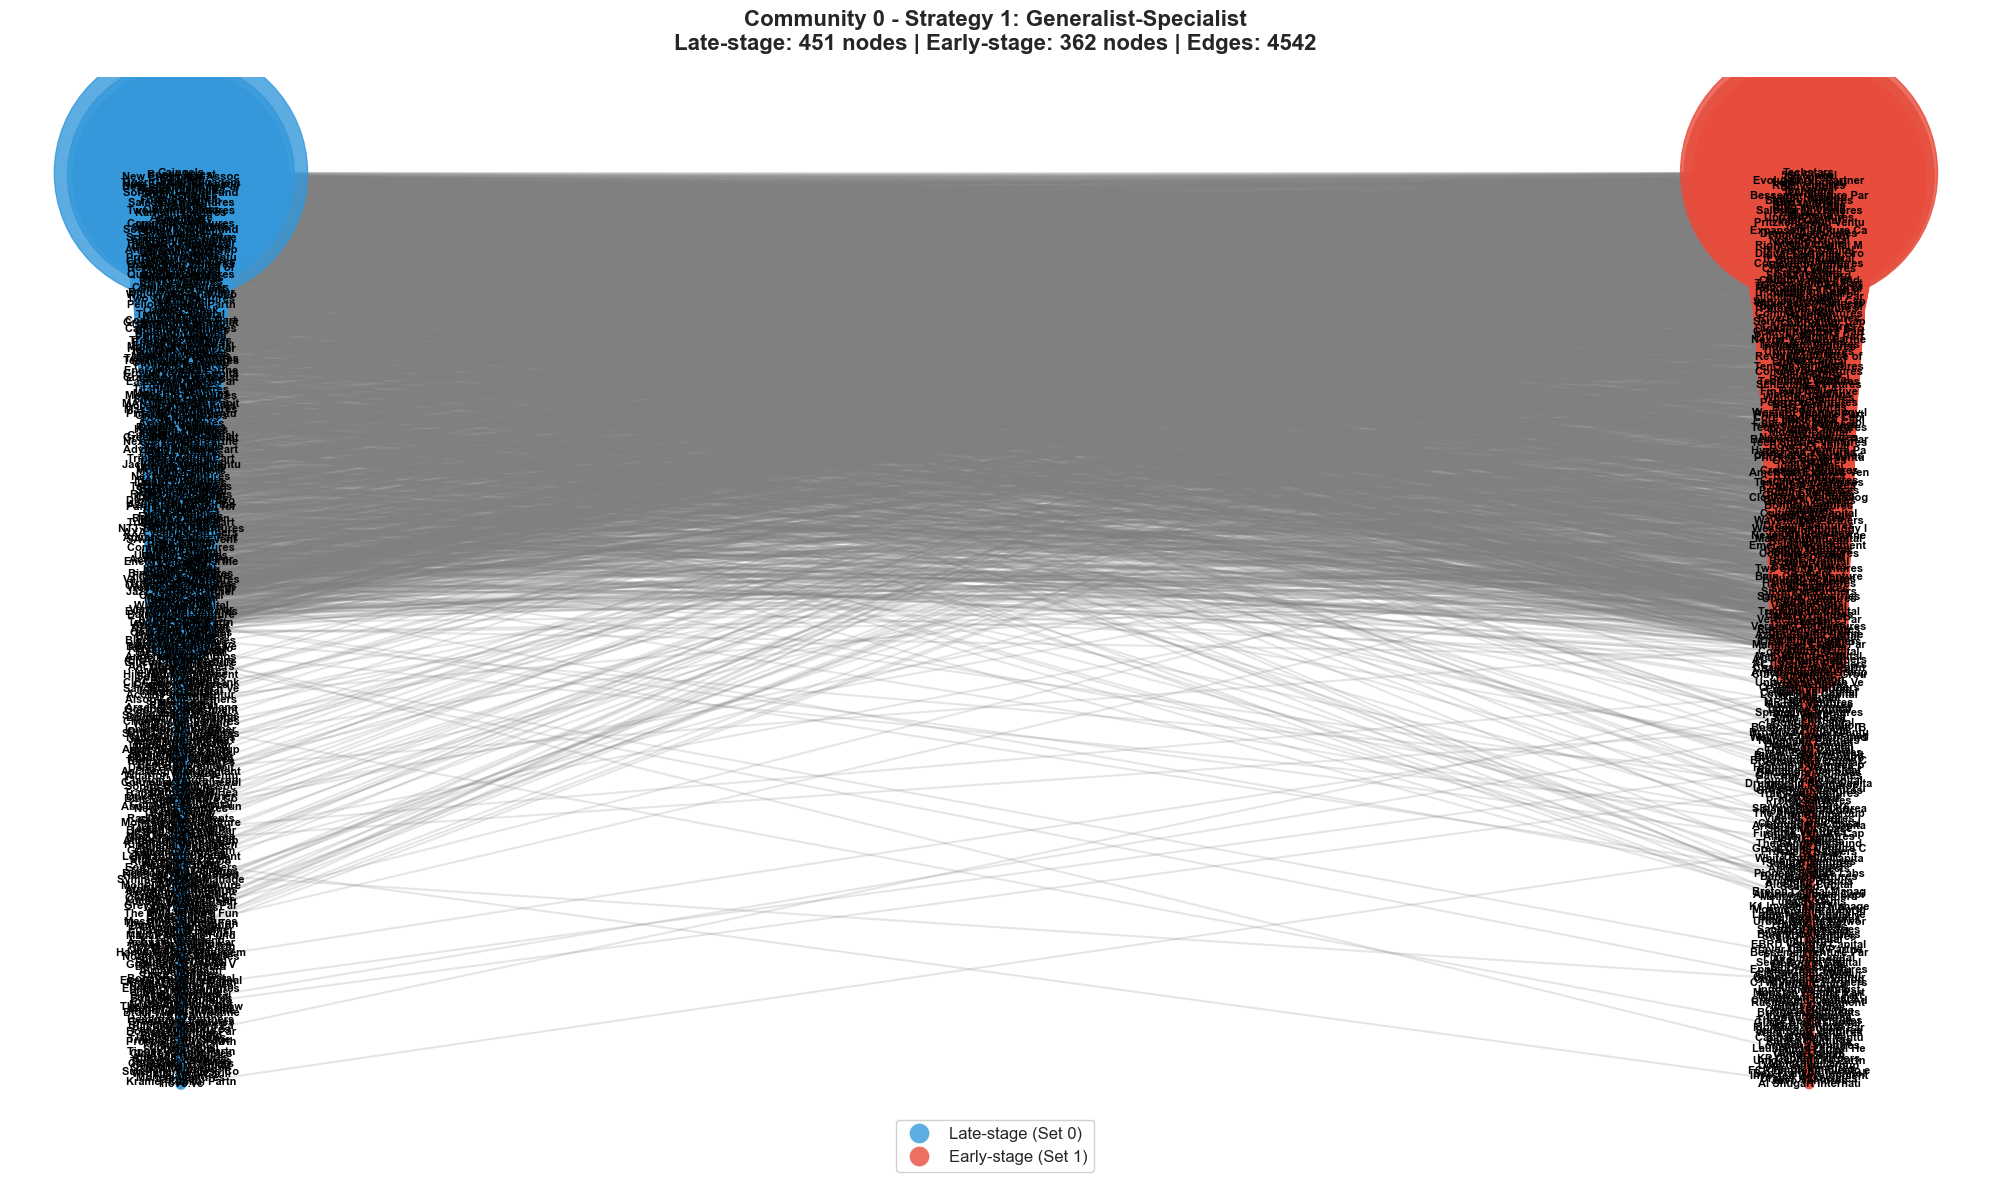



Processing Community 1...
Community 1: 257 + 149 generalists, 33 connected specialists (from 165 candidates), 349 detached specialists (from 3491 candidates)
Selected 788 nodes with 1846 edges
Set 0: 571, Set 1: 217
Community 1: 257 + 149 generalists, 33 connected specialists (from 165 candidates), 349 detached specialists (from 3491 candidates)
Selected 788 nodes with 1846 edges
Set 0: 571, Set 1: 217


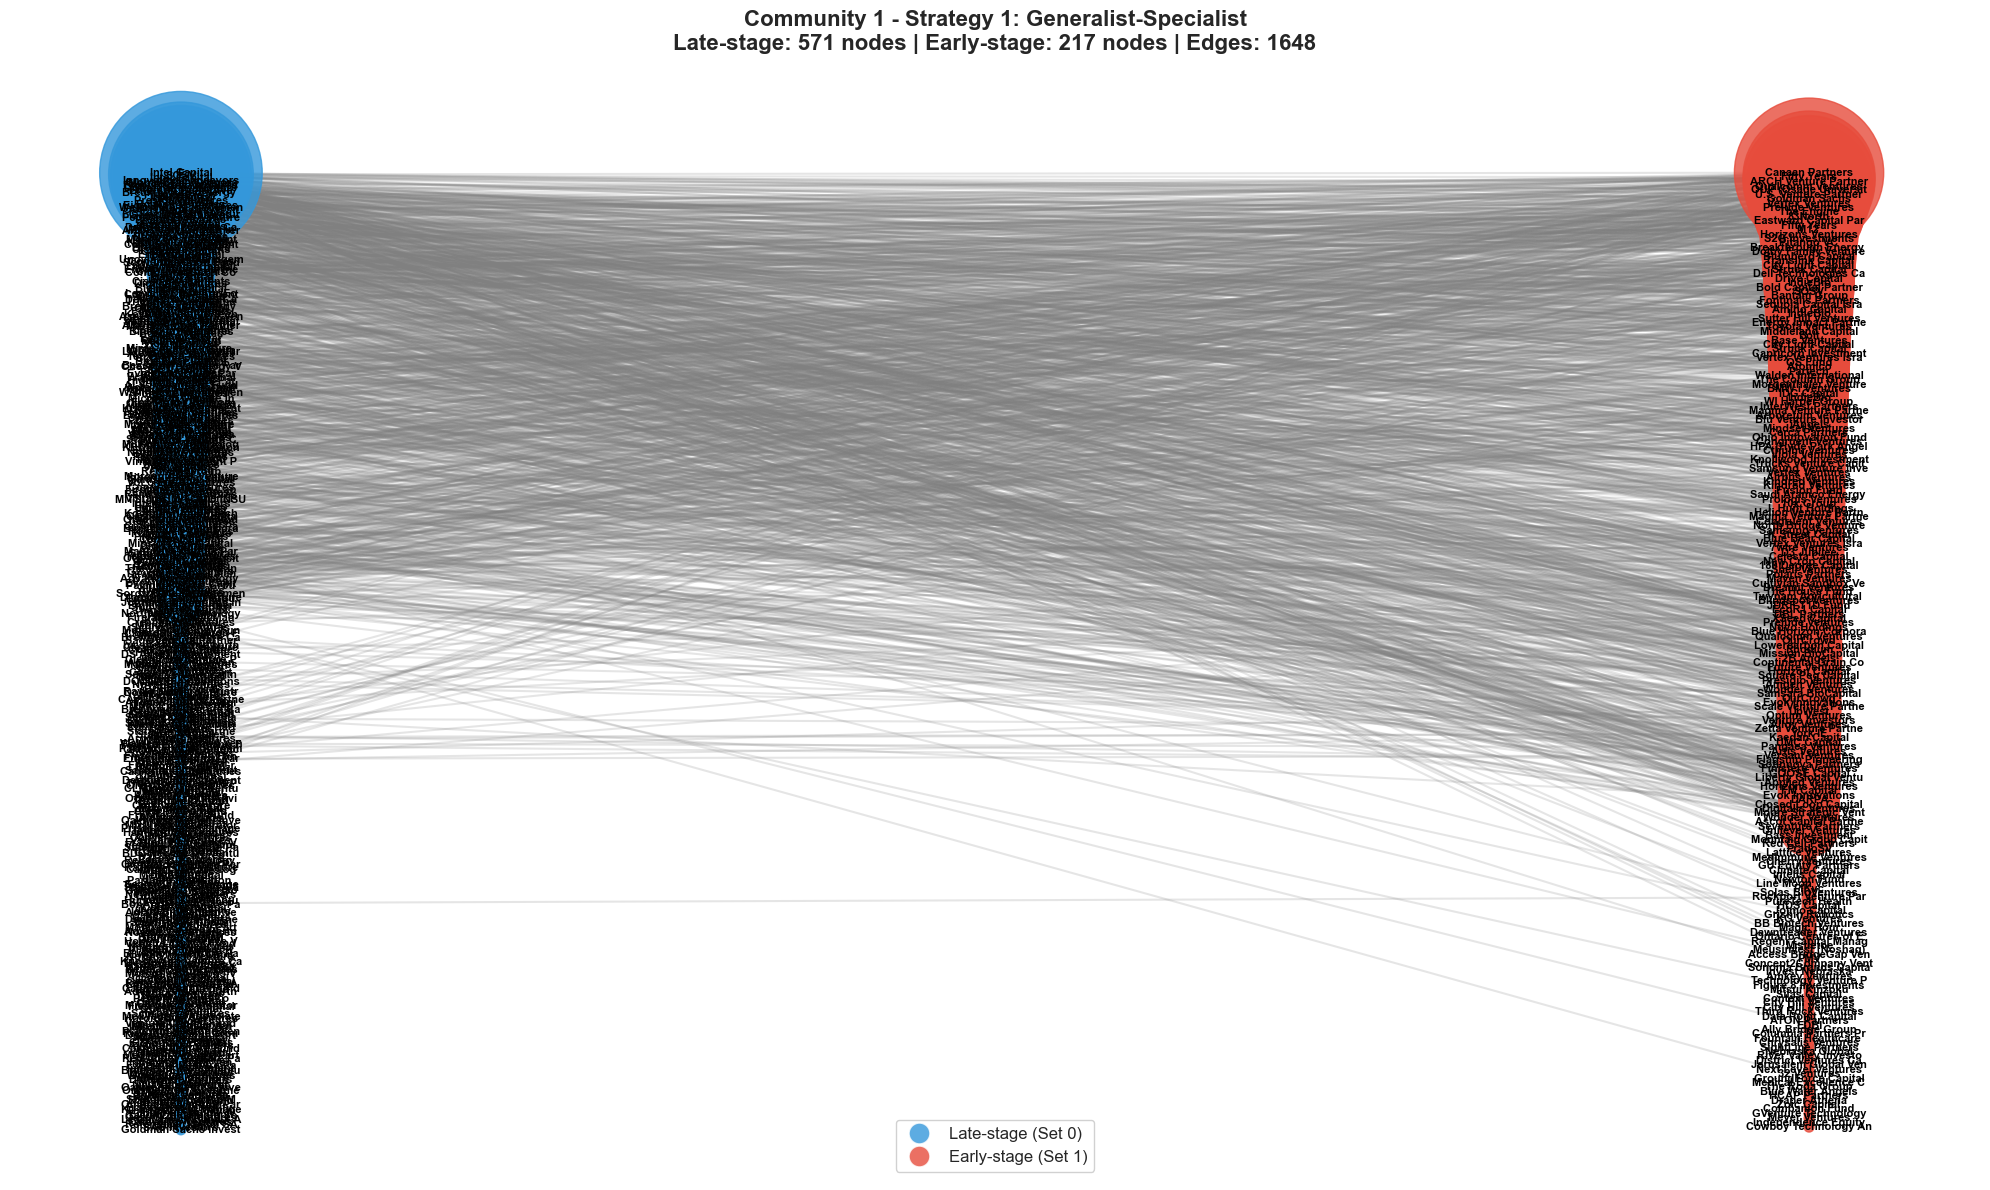



Processing Community 2...
Community 2: 291 + 113 generalists, 77 connected specialists (from 386 candidates), 325 detached specialists (from 3250 candidates)
Selected 806 nodes with 12284 edges
Set 0: 636, Set 1: 170
Community 2: 291 + 113 generalists, 77 connected specialists (from 386 candidates), 325 detached specialists (from 3250 candidates)
Selected 806 nodes with 12284 edges
Set 0: 636, Set 1: 170


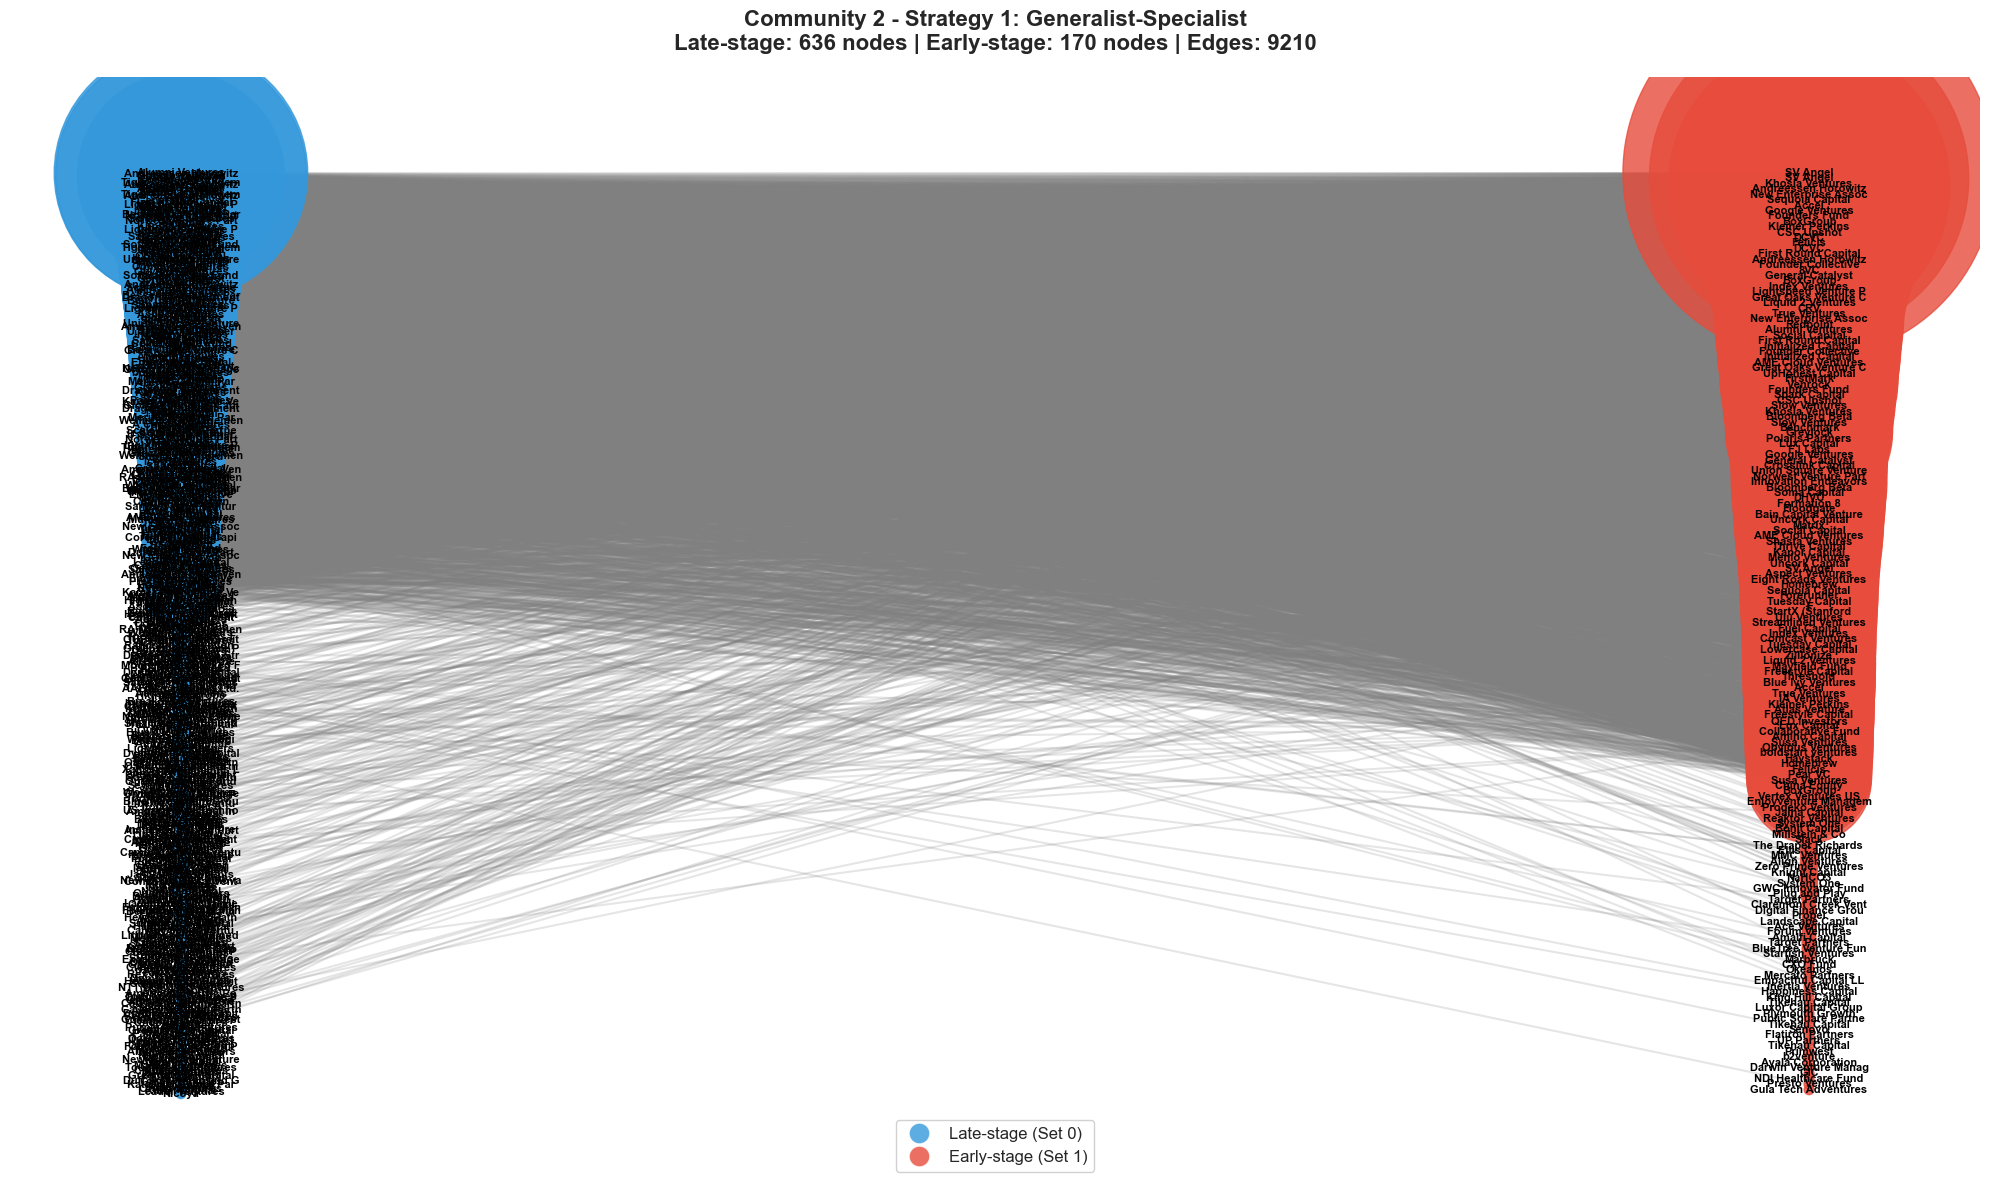

In [44]:
# Apply Strategy 1: Generalist-Specialist Filtering
target_communities = [0, 1, 2]

print("="*80)
print("STRATEGY 1: GENERALIST-SPECIALIST FILTERING")
print("="*80)

for community_id in target_communities:
    print(f"\nProcessing Community {community_id}...")
    
    # Get nodes using Strategy 1
    selected_nodes = get_nestedness_revealing_nodes(
        nodes_with_degree, community_id, edges_df, 
        pct_generalists=0.1, pct_specialists=0.2, get_specialists_detached=True, pct_detached_specialists=0.1
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    print(f"Selected {len(selected_nodes)} nodes with {len(selected_edges)} edges")
    print(f"Set 0: {(selected_nodes['set'] == 0).sum()}, Set 1: {(selected_nodes['set'] == 1).sum()}")
    
    # Create visualization
    g = create_bipartite_graph(selected_nodes, selected_edges, community_id, 
                               "Strategy 1: Generalist-Specialist")
    
    plt.show()
    print()

## Nestedness Calculation with Null Models

Calculate nestedness (NODF) for selected nodes using the Curveball null model approach.

### Helper Function: Filter Zero Rows and Columns

In [20]:
def filter_zero_rows_cols(adjacency_matrix):
    """
    Filter out rows and columns that contain only zeros from adjacency matrix.
    This prevents the 'Input matrix rows with only zeros, abort' error.
    
    Parameters:
    -----------
    adjacency_matrix : np.ndarray
        Binary adjacency matrix
    
    Returns:
    --------
    filtered_matrix : np.ndarray
        Filtered adjacency matrix with no zero-only rows or columns
    row_indices : np.ndarray
        Boolean mask indicating which rows were kept
    col_indices : np.ndarray
        Boolean mask indicating which columns were kept
    """
    # Identify rows and columns with at least one non-zero entry
    row_mask = adjacency_matrix.sum(axis=1) > 0
    col_mask = adjacency_matrix.sum(axis=0) > 0
    
    # Filter the matrix
    filtered_matrix = adjacency_matrix[row_mask][:, col_mask]
    
    return filtered_matrix, row_mask, col_mask

### Updated Nestedness Calculation with Matrix Filtering

In [21]:
def calculate_nestedness_with_null_model(selected_nodes, selected_edges, 
                                         label="Network", n_iterations=100, n_iterations_cv=10000):
    """
    Calculate nestedness (NODF) for a bipartite network with null model comparison.
    Automatically filters out zero-only rows and columns from the adjacency matrix.
    
    Parameters:
    -----------
    selected_nodes : pd.DataFrame
        DataFrame with columns: 'node', 'set' (0 or 1 for bipartite sets)
    selected_edges : pd.DataFrame
        DataFrame with columns: 'Source', 'Target'
    label : str
        Label for the network (e.g., "Community 0")
    n_iterations : int
        Number of null models to generate (default: 100)
    n_iterations_cv : int
        Number of curveball iterations per null model (default: 10000)
    
    Returns:
    --------
    dict with keys:
        - 'observed_nodf': observed nestedness score
        - 'null_mean': mean of null model scores
        - 'null_std': standard deviation of null model scores
        - 'z_score': z-score of observed vs null
        - 'p_value': empirical p-value
        - 'null_scores': list of all null model scores
        - 'adjacency_matrix': the adjacency matrix used
        - 'num_edges': number of edges
        - 'left_nodes': number of left nodes
        - 'right_nodes': number of right nodes
    """
    
    # Separate nodes by bipartite set
    left_nodes = selected_nodes[selected_nodes['set'] == 0]['node'].values
    right_nodes = selected_nodes[selected_nodes['set'] == 1]['node'].values
    
    if len(left_nodes) == 0 or len(right_nodes) == 0:
        print(f"ERROR: {label} - Empty bipartite set")
        return None
    
    # Create node indices
    left_indices = {node: i for i, node in enumerate(left_nodes)}
    right_indices = {node: j for j, node in enumerate(right_nodes)}
    
    # Create adjacency matrix
    adjacency_matrix = np.zeros((len(left_nodes), len(right_nodes)), dtype=np.int8)
    
    for _, edge in selected_edges.iterrows():
        source = edge['Source']
        target = edge['Target']
        
        # Determine which is left and which is right
        if source in left_indices and target in right_indices:
            adjacency_matrix[left_indices[source], right_indices[target]] = 1
        elif target in left_indices and source in right_indices:
            adjacency_matrix[left_indices[target], right_indices[source]] = 1
    
    # FILTER: Remove rows and columns with only zeros
    adjacency_matrix_filtered, row_mask, col_mask = filter_zero_rows_cols(adjacency_matrix)
    
    num_edges = int(adjacency_matrix_filtered.sum())
    density = adjacency_matrix_filtered.mean() if adjacency_matrix_filtered.size > 0 else 0
    
    print(f"\n{label}:")
    print(f"  Original matrix shape: {adjacency_matrix.shape[0]} x {adjacency_matrix.shape[1]}")
    print(f"  Filtered matrix shape: {adjacency_matrix_filtered.shape[0]} x {adjacency_matrix_filtered.shape[1]}")
    print(f"  Edges: {num_edges}, Density: {density:.4f}")
    
    # Check if matrix has any edges
    if num_edges == 0:
        print(f"  ERROR: No edges in adjacency matrix after filtering")
        return None
    
    # Check if filtered matrix is valid (no zero-only rows/cols)
    if adjacency_matrix_filtered.shape[0] == 0 or adjacency_matrix_filtered.shape[1] == 0:
        print(f"  ERROR: Filtered matrix is empty")
        return None
    
    # Calculate observed nestedness
    try:
        calculator = NestednessCalculator(adjacency_matrix_filtered)
        observed_nodf = calculator.nodf(adjacency_matrix_filtered)
        print(f"  Observed NODF: {observed_nodf:.4f}")
    except Exception as e:
        print(f"  ERROR calculating observed NODF: {e}")
        return None
    
    # Generate null models using curveball algorithm
    null_scores = []
    
    print(f"  Generating {n_iterations} null models...")
    for i in tqdm(range(n_iterations), desc=f"{label}", leave=False):
        try:
            # Generate null model matrix
            M = adjacency_matrix_filtered.copy()
            r_hp = find_presences(M)
            RM = curve_ball(M, r_hp, n_iterations_cv)
            
            null_matrix = RM.astype(adjacency_matrix_filtered.dtype)
            
            # Calculate nestedness of null model
            calculator_null = NestednessCalculator(null_matrix)
            null_score = calculator_null.nodf(null_matrix)
            null_scores.append(null_score)
            
        except Exception as e:
            print(f"    Warning: Error in null model iteration {i}: {e}")
            continue
    
    if len(null_scores) == 0:
        print(f"  ERROR: No valid null models generated")
        return None
    
    # Calculate statistics
    null_scores_array = np.array(null_scores)
    null_mean = np.mean(null_scores_array)
    null_std = np.std(null_scores_array)
    
    if null_std > 0:
        z_score = (observed_nodf - null_mean) / null_std
    else:
        z_score = np.nan
    
    # Calculate empirical p-value
    # Adding 1 to numerator and denominator to avoid p=0
    p_value = (np.sum(null_scores_array >= observed_nodf) + 1) / (len(null_scores_array) + 1)
    
    significance = 'significant' if p_value < 0.05 else 'not significant'
    
    print(f"  Null model: mean={null_mean:.4f}, std={null_std:.4f}")
    print(f"  Z-score: {z_score:.4f}")
    print(f"  P-value: {p_value:.4f} ({significance})")
    
    return {
        'label': label,
        'observed_nodf': observed_nodf,
        'null_mean': null_mean,
        'null_std': null_std,
        'z_score': z_score,
        'p_value': p_value,
        'null_scores': null_scores,
        'adjacency_matrix': adjacency_matrix_filtered,
        'num_edges': num_edges,
        'left_nodes': adjacency_matrix_filtered.shape[0],
        'right_nodes': adjacency_matrix_filtered.shape[1],
        'density': density
    }

In [11]:
def plot_nestedness_null_distribution(nestedness_results, save_path=None):
    """
    Plot histogram of null model distribution with observed nestedness.
    
    Parameters:
    -----------
    nestedness_results : dict or list of dict
        Results from calculate_nestedness_with_null_model()
    save_path : str, optional
        Path to save the figure
    """
    # Handle single result or list of results
    if isinstance(nestedness_results, dict):
        nestedness_results = [nestedness_results]
    
    # Filter out None results
    nestedness_results = [r for r in nestedness_results if r is not None]
    
    if len(nestedness_results) == 0:
        print("No valid results to plot")
        return
    
    n_results = len(nestedness_results)
    fig, axes = plt.subplots(1, n_results, figsize=(8*n_results, 6))
    
    # Ensure axes is always a list
    if n_results == 1:
        axes = [axes]
    
    for i, result in enumerate(nestedness_results):
        ax = axes[i]
        
        # Plot histogram of null distribution
        ax.hist(result['null_scores'], bins=30, alpha=0.7, color='skyblue', 
                edgecolor='black', label='Null models')
        
        # Add vertical line for observed value
        ax.axvline(result['observed_nodf'], color='red', linestyle='--', 
                   linewidth=2, label=f"Observed NODF={result['observed_nodf']:.4f}")
        
        # Add vertical line for null mean
        ax.axvline(result['null_mean'], color='black', linestyle='-', 
                   linewidth=1.5, alpha=0.7, label=f"Null mean={result['null_mean']:.4f}")
        
        # Shaded area for ±1 std
        ax.axvspan(result['null_mean'] - result['null_std'], 
                   result['null_mean'] + result['null_std'],
                   alpha=0.2, color='gray', label='±1 SD')
        
        # Title with statistics
        significance = '✓ Significant' if result['p_value'] < 0.05 else '✗ Not Significant'
        title = (f"{result['label']}\n"
                f"Z-score: {result['z_score']:.4f}, P-value: {result['p_value']:.4f}\n"
                f"{significance}")
        ax.set_title(title, fontsize=14, fontweight='bold')
        
        ax.set_xlabel('Nestedness (NODF)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add text box with network info
        info_text = (f"Nodes: {result['left_nodes']} × {result['right_nodes']}\n"
                    f"Edges: {result['num_edges']}\n"
                    f"Density: {result['density']:.4f}")
        ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                verticalalignment='top', horizontalalignment='right', fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

### Apply Nestedness Calculation to Communities 0, 1, and 2

Using the Generalist-Specialist filtering strategy.

In [48]:
# Calculate nestedness for communities 0, 1, and 2 using Strategy 1
print("="*80)
print("NESTEDNESS CALCULATION - GENERALIST-SPECIALIST FILTERING")
print("="*80)

nestedness_results_all = []

for community_id in target_communities:
    print(f"\n{'='*60}")
    print(f"COMMUNITY {community_id}")
    print(f"{'='*60}")
    
    # Get nodes using Strategy 1 (Generalist-Specialist)
    selected_nodes = get_nestedness_revealing_nodes(
        nodes_with_degree, community_id, edges_df, 
        pct_generalists=0.05, pct_specialists=1, get_specialists_detached=True, pct_detached_specialists=0.05
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    # Calculate nestedness with null model
    result = calculate_nestedness_with_null_model(
        selected_nodes, 
        selected_edges,
        label=f"Community {community_id}",
        n_iterations=100,
        n_iterations_cv=10000
    )
    
    if result is not None:
        nestedness_results_all.append(result)

print(f"\n{'='*80}")
print(f"NESTEDNESS CALCULATION COMPLETE")
print(f"Successfully calculated nestedness for {len(nestedness_results_all)} communities")
print(f"{'='*80}")

NESTEDNESS CALCULATION - GENERALIST-SPECIALIST FILTERING

COMMUNITY 0
Community 0: 114 + 96 generalists, 83 connected specialists (from 83 candidates), 195 detached specialists (from 3919 candidates)

Community 0:
  Original matrix shape: 257 x 231
  Filtered matrix shape: 170 x 134
  Edges: 1981, Density: 0.0870
  Observed NODF: 0.2088
  Generating 100 null models...
Community 0: 114 + 96 generalists, 83 connected specialists (from 83 candidates), 195 detached specialists (from 3919 candidates)

Community 0:
  Original matrix shape: 257 x 231
  Filtered matrix shape: 170 x 134
  Edges: 1981, Density: 0.0870
  Observed NODF: 0.2088
  Generating 100 null models...


  Null model: mean=0.2192, std=0.0047
  Z-score: -2.1781
  P-value: 0.9802 (not significant)

COMMUNITY 1
Community 1: 128 + 74 generalists, 95 connected specialists (from 95 candidates), 188 detached specialists (from 3765 candidates)

Community 1:
  Original matrix shape: 352 x 133
  Filtered matrix shape: 188 x 105
  Edges: 697, Density: 0.0353
  Observed NODF: 0.0729
  Generating 100 null models...
Community 1: 128 + 74 generalists, 95 connected specialists (from 95 candidates), 188 detached specialists (from 3765 candidates)

Community 1:
  Original matrix shape: 352 x 133
  Filtered matrix shape: 188 x 105
  Edges: 697, Density: 0.0353
  Observed NODF: 0.0729
  Generating 100 null models...


  Null model: mean=0.0760, std=0.0017
  Z-score: -1.8280
  P-value: 0.9802 (not significant)

COMMUNITY 2
Community 2: 145 + 56 generalists, 250 connected specialists (from 250 candidates), 179 detached specialists (from 3589 candidates)

Community 2:
  Original matrix shape: 526 x 104
  Filtered matrix shape: 415 x 76
  Edges: 3908, Density: 0.1239
  Observed NODF: 0.3138
  Generating 100 null models...
Community 2: 145 + 56 generalists, 250 connected specialists (from 250 candidates), 179 detached specialists (from 3589 candidates)

Community 2:
  Original matrix shape: 526 x 104
  Filtered matrix shape: 415 x 76
  Edges: 3908, Density: 0.1239
  Observed NODF: 0.3138
  Generating 100 null models...


  Null model: mean=0.3331, std=0.0035
  Z-score: -5.5082
  P-value: 1.0000 (not significant)

NESTEDNESS CALCULATION COMPLETE
Successfully calculated nestedness for 3 communities


C:\Users\joaom\AppData\Local\Temp\ipykernel_5900\480444675.py:70: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joaom\AppData\Local\Temp\ipykernel_5900\480444675.py:73: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


Figure saved to: ../reports/figures/us/nestedness_generalist_specialist_communities_0_1_2.png


d:\Repositories\memoire\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


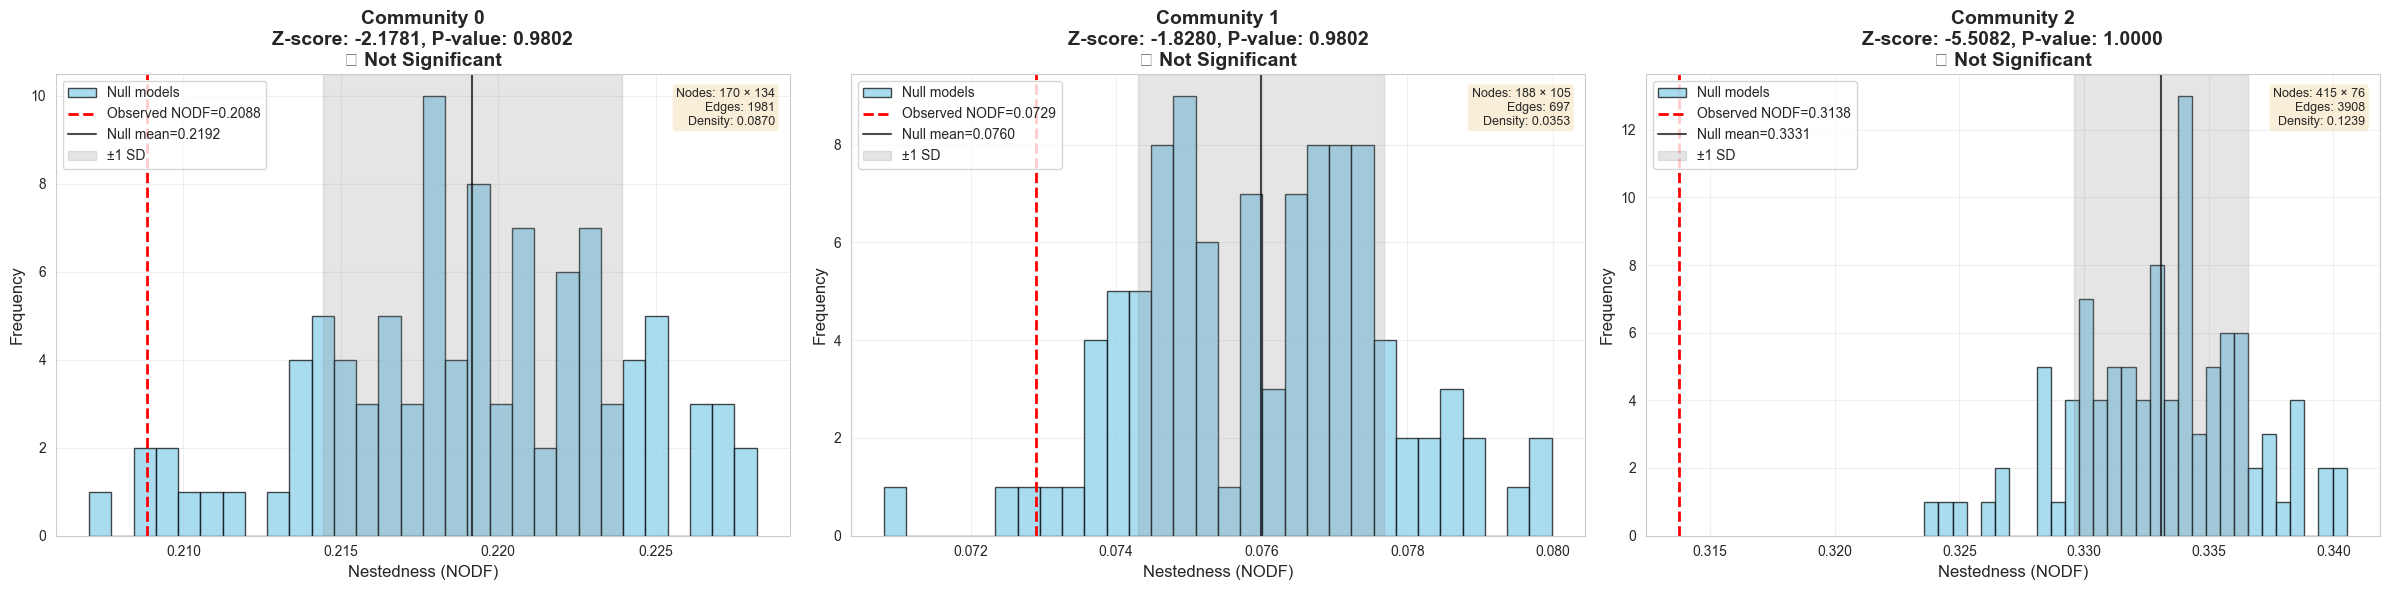

In [ ]:
# Plot all nestedness results together
plot_nestedness_null_distribution(
    nestedness_results_all,
    save_path='../../reports/figures/us/nestedness_generalist_specialist_communities_0_1_2.png'
)

In [50]:
Erro

NameError: name 'Erro' is not defined

In [ ]:
# Create summary table
if len(nestedness_results_all) > 0:
    summary_data = []
    for result in nestedness_results_all:
        summary_data.append({
            'Community': result['label'],
            'Left Nodes': result['left_nodes'],
            'Right Nodes': result['right_nodes'],
            'Edges': result['num_edges'],
            'Density': result['density'],
            'Observed NODF': result['observed_nodf'],
            'Null Mean': result['null_mean'],
            'Null Std': result['null_std'],
            'Z-score': result['z_score'],
            'P-value': result['p_value'],
            'Significant': 'Yes' if result['p_value'] < 0.05 else 'No'
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*80)
    print("NESTEDNESS SUMMARY TABLE")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("\n" + "="*80)


NESTEDNESS SUMMARY TABLE
  Community  Left Nodes  Right Nodes  Edges  Density  Observed NODF  Null Mean  Null Std   Z-score  P-value Significant
Community 0          28           12    100 0.297619       0.514143   0.585526  0.012657 -5.639653 1.000000          No
Community 2          30           10    107 0.356667       0.498570   0.510653  0.005774 -2.092541 0.980198          No



Possible interpretation: the more specialists and generalists dependend on them, more nested. Then, the graphs with more points (in proportion to communities' size, which is uniform accross 0, 1, and 2), more nested.

## Strategy 2: Degree-Ratio Filtering

Select nodes with different degree ratios to show nestedness gradient:
- High degree: Core generalists
- Medium degree: Intermediate connectors
- Low degree: Specialists

This creates a clear visual gradient showing nested structure.

In [ ]:
def get_degree_ratio_nodes(df, community_id, edges_df, n_high=15, n_medium=10, n_low=15):
    """
    Select nodes with different degree ratios to show nestedness gradient:
    - High degree: Core generalists
    - Medium degree: Intermediate connectors
    - Low degree: Specialists
    
    This creates a clear visual gradient showing nested structure.
    """
    community_nodes = df[df['community_id'] == community_id].copy()
    
    # Split by set
    left_nodes = community_nodes[community_nodes['set'] == 0].sort_values('degree', ascending=False)
    right_nodes = community_nodes[community_nodes['set'] == 1].sort_values('degree', ascending=False)
    
    def select_stratified(nodes_df, n_high, n_medium, n_low):
        total = len(nodes_df)
        if total == 0:
            return pd.DataFrame()
        
        # Define percentile thresholds
        high_threshold = int(total * 0.1)  # Top 10%
        medium_start = int(total * 0.4)    # 40-60%
        medium_end = int(total * 0.6)
        low_start = int(total * 0.9)       # Bottom 10%
        
        high = nodes_df.iloc[:high_threshold].head(n_high)
        medium = nodes_df.iloc[medium_start:medium_end].head(n_medium)
        low = nodes_df.iloc[low_start:].head(n_low)
        
        return pd.concat([high, medium, low], ignore_index=True)
    
    left_selected = select_stratified(left_nodes, n_high, n_medium, n_low)
    right_selected = select_stratified(right_nodes, n_high, n_medium, n_low)
    
    result = pd.concat([left_selected, right_selected], ignore_index=True)
    
    print(f"Community {community_id}: Selected {len(result)} nodes across degree spectrum")
    print(f"  Left: high={len(left_selected[left_selected['degree'] > left_nodes['degree'].quantile(0.9)])}, "
          f"low={len(left_selected[left_selected['degree'] < left_nodes['degree'].quantile(0.2)])}")
    
    return result

STRATEGY 3: DEGREE-RATIO FILTERING

Processing Community 0...
Community 0: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 306 edges
Set 0: 40, Set 1: 40


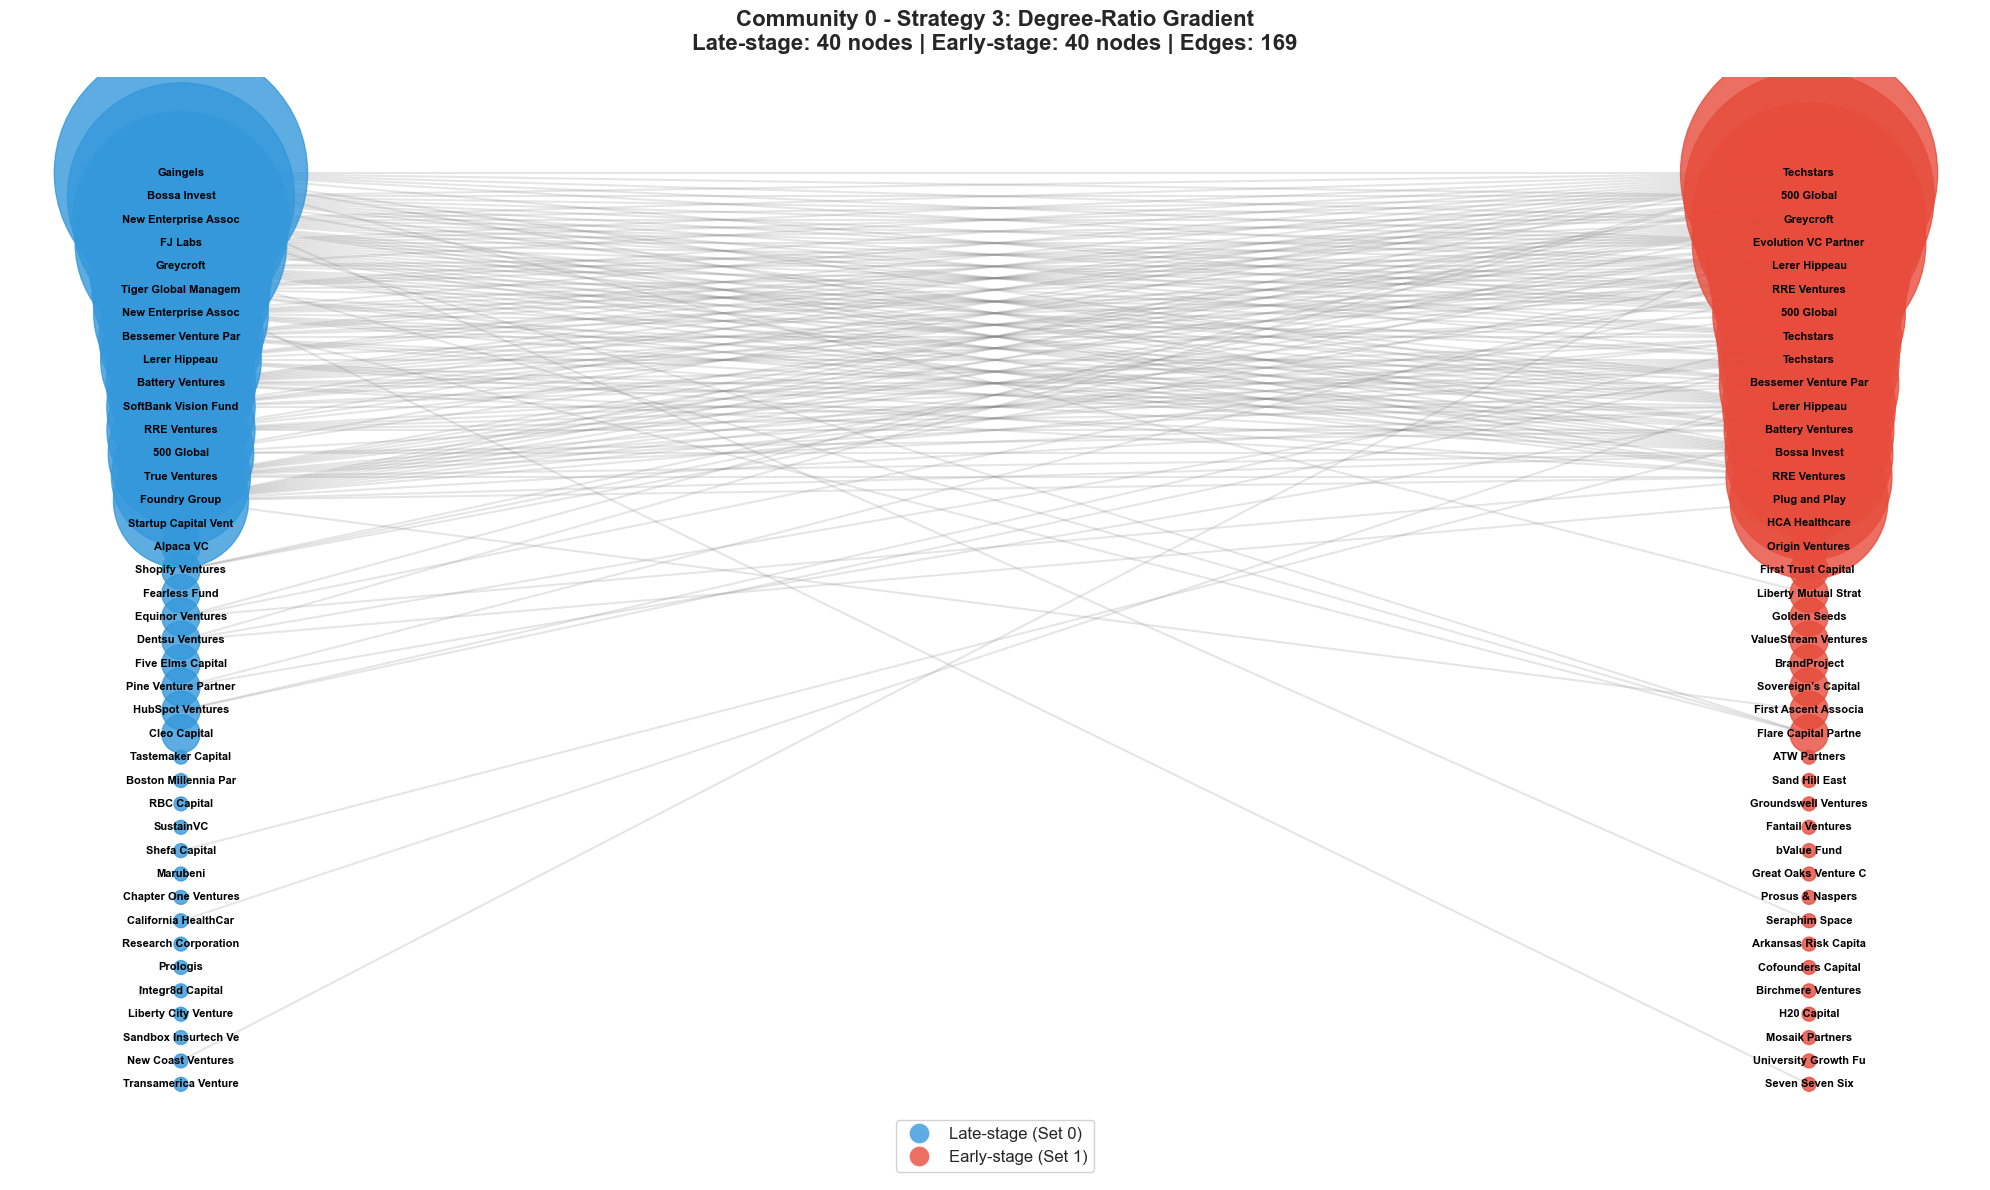



Processing Community 1...
Community 1: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 62 edges
Set 0: 40, Set 1: 40


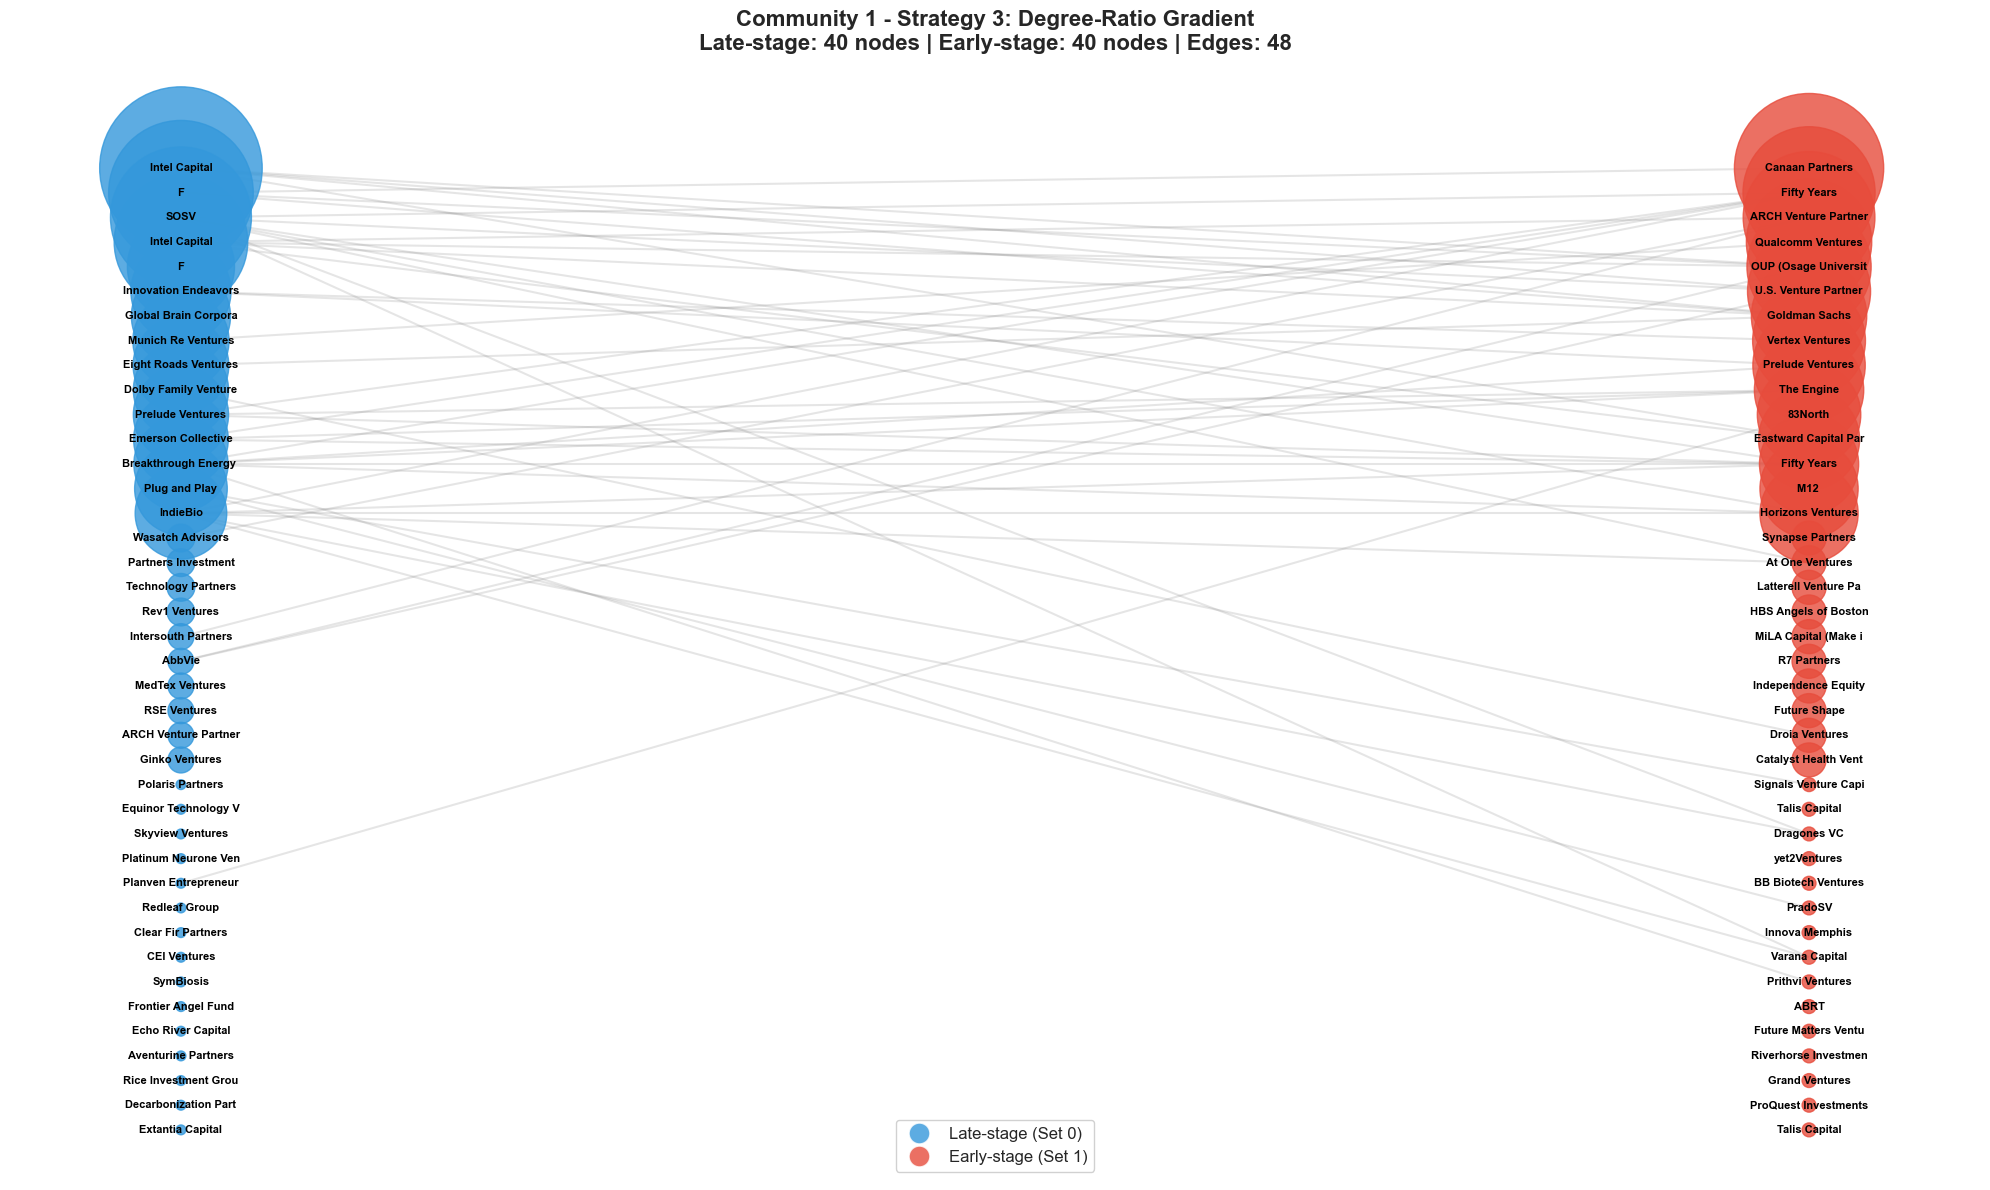



Processing Community 2...
Community 2: Selected 80 nodes across degree spectrum
  Left: high=15, low=15
Selected 80 nodes with 647 edges
Set 0: 40, Set 1: 40


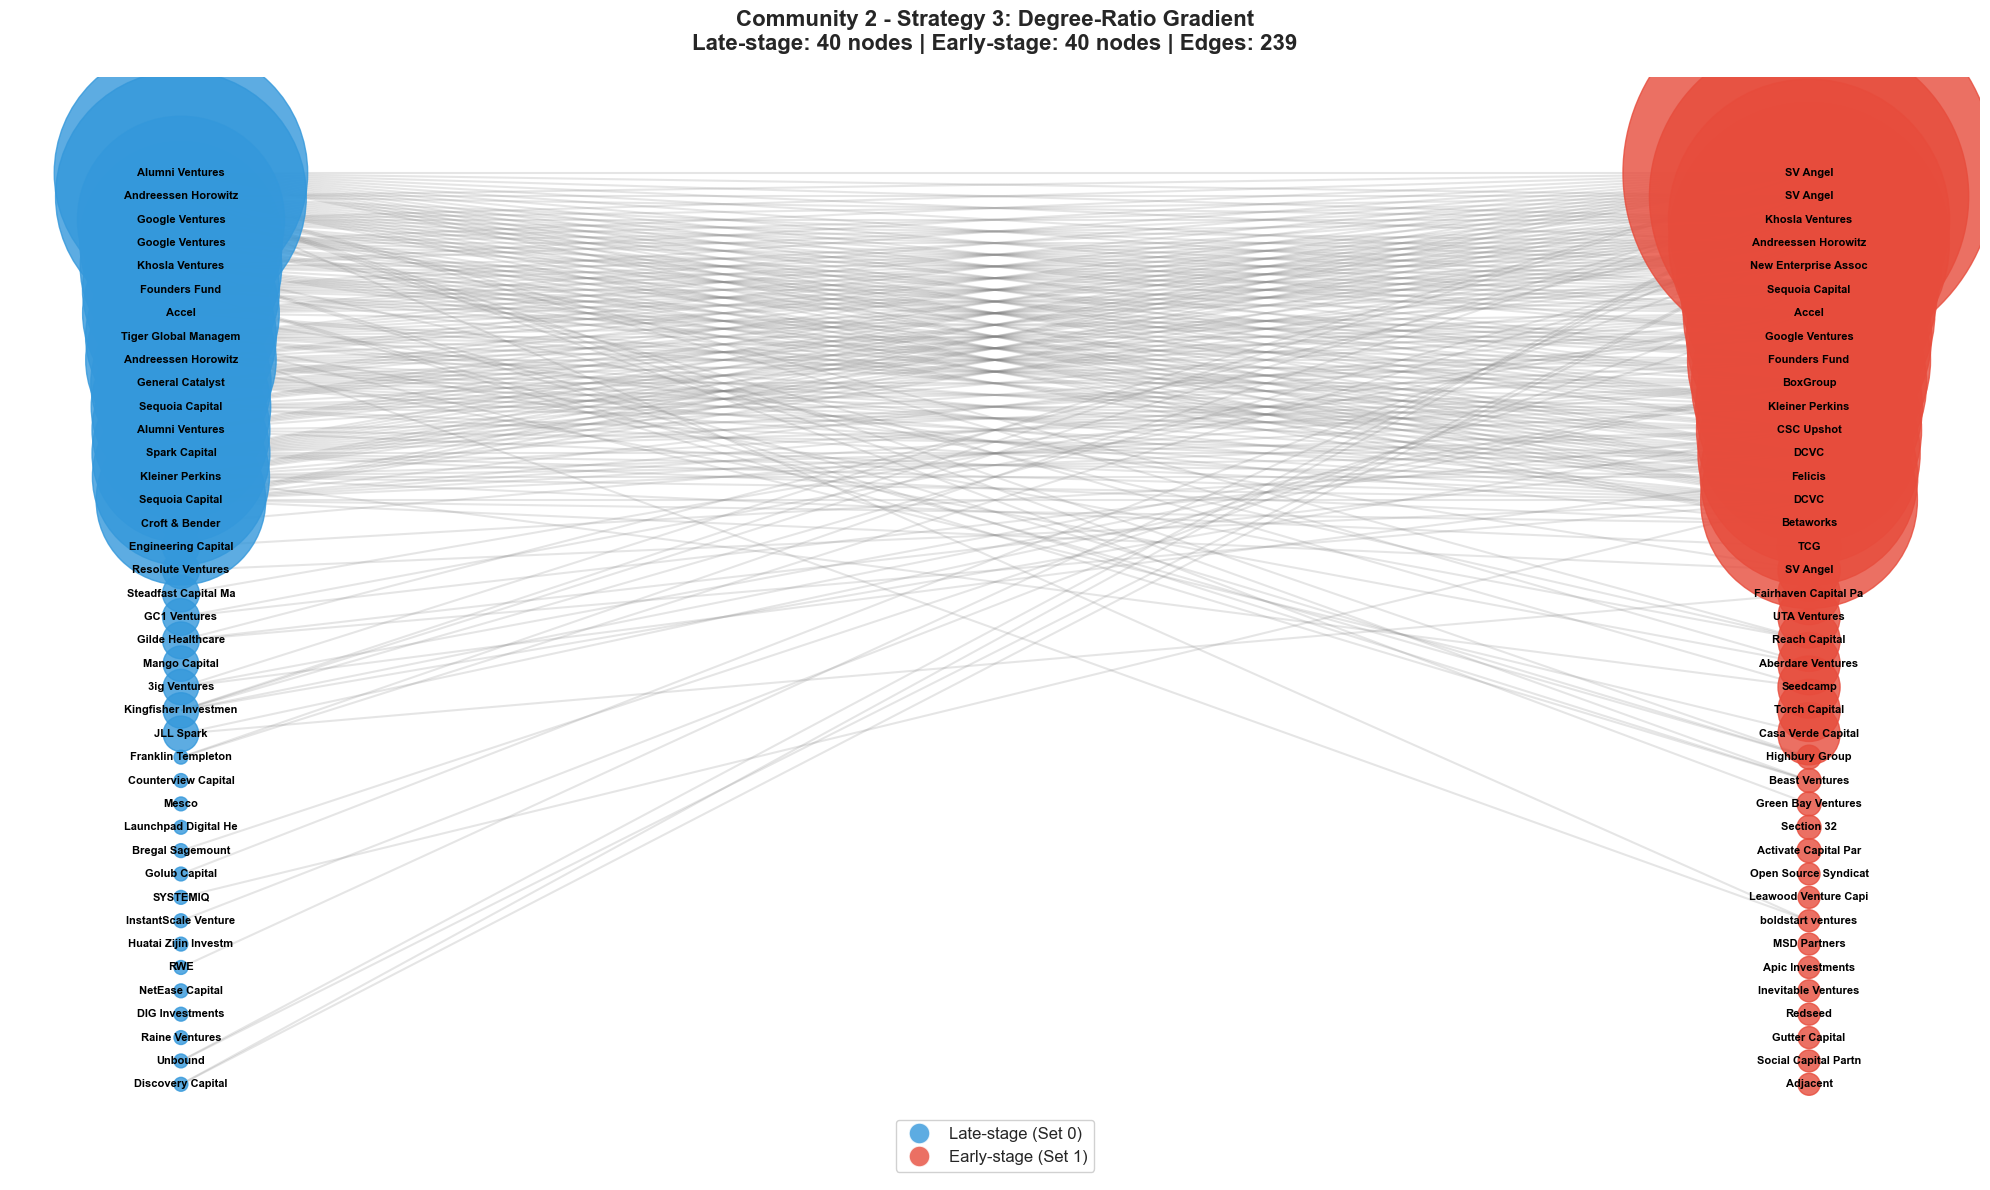

In [ ]:
# Apply Strategy 3: Degree-Ratio Filtering
print("="*80)
print("STRATEGY 3: DEGREE-RATIO FILTERING")
print("="*80)

for community_id in target_communities:
    print(f"\nProcessing Community {community_id}...")
    
    # Get nodes using Strategy 3
    selected_nodes = get_degree_ratio_nodes(
        nodes_with_degree, community_id, edges_df,
        n_high=15, n_medium=10, n_low=15
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    print(f"Selected {len(selected_nodes)} nodes with {len(selected_edges)} edges")
    print(f"Set 0: {(selected_nodes['set'] == 0).sum()}, Set 1: {(selected_nodes['set'] == 1).sum()}")
    
    # Create visualization
    g = create_bipartite_graph(selected_nodes, selected_edges, community_id,
                               "Strategy 3: Degree-Ratio Gradient")
    
    plt.show()
    print()

### Apply Nestedness Calculation to Communities 0, 1, and 2

Using the Degree-Ratio filtering strategy.

In [51]:
# Calculate nestedness for communities 0, 1, and 2 using Strategy 2 (Degree-Ratio)
print("="*80)
print("NESTEDNESS CALCULATION - DEGREE-RATIO FILTERING")
print("="*80)

nestedness_results_degree_ratio = []

for community_id in target_communities:
    print(f"\n{'='*60}")
    print(f"COMMUNITY {community_id}")
    print(f"{'='*60}")
    
    # Get nodes using Strategy 2 (Degree-Ratio)
    selected_nodes = get_degree_ratio_nodes(
        nodes_with_degree, community_id, edges_df,
        n_high=100, n_medium=30, n_low=1000
    )
    
    # Get edges between selected nodes
    selected_node_ids = set(selected_nodes['node'].values)
    selected_edges = edges_df[
        (edges_df['Source'].isin(selected_node_ids)) & 
        (edges_df['Target'].isin(selected_node_ids))
    ]
    
    # Calculate nestedness with null model
    result = calculate_nestedness_with_null_model(
        selected_nodes, 
        selected_edges,
        label=f"Community {community_id}",
        n_iterations=100,
        n_iterations_cv=10000
    )
    
    if result is not None:
        nestedness_results_degree_ratio.append(result)

print(f"\n{'='*80}")
print(f"NESTEDNESS CALCULATION COMPLETE")
print(f"Successfully calculated nestedness for {len(nestedness_results_degree_ratio)} communities")
print(f"{'='*80}")

NESTEDNESS CALCULATION - DEGREE-RATIO FILTERING

COMMUNITY 0
Community 0: Selected 682 nodes across degree spectrum
  Left: high=100, low=228

Community 0:
  Original matrix shape: 358 x 324
  Filtered matrix shape: 236 x 197
  Edges: 2129, Density: 0.0458
  Observed NODF: 0.1439
  Generating 100 null models...


  Null model: mean=0.1636, std=0.0035
  Z-score: -5.6588
  P-value: 1.0000 (not significant)

COMMUNITY 1
Community 1: Selected 668 nodes across degree spectrum
  Left: high=100, low=258

Community 1:
  Original matrix shape: 388 x 280
  Filtered matrix shape: 186 x 182
  Edges: 819, Density: 0.0242
  Observed NODF: 0.0554
  Generating 100 null models...


  Null model: mean=0.0631, std=0.0016
  Z-score: -4.8810
  P-value: 1.0000 (not significant)

COMMUNITY 2
Community 2: Selected 664 nodes across degree spectrum
  Left: high=100, low=291

Community 2:
  Original matrix shape: 421 x 243
  Filtered matrix shape: 375 x 197
  Edges: 4826, Density: 0.0653
  Observed NODF: 0.2578
  Generating 100 null models...


  Null model: mean=0.2639, std=0.0034
  Z-score: -1.8236
  P-value: 0.9604 (not significant)

NESTEDNESS CALCULATION COMPLETE
Successfully calculated nestedness for 3 communities


C:\Users\joaom\AppData\Local\Temp\ipykernel_5900\480444675.py:70: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joaom\AppData\Local\Temp\ipykernel_5900\480444675.py:73: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


Figure saved to: ../reports/figures/us/nestedness_degree_ratio_communities_0_1_2.png


d:\Repositories\memoire\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


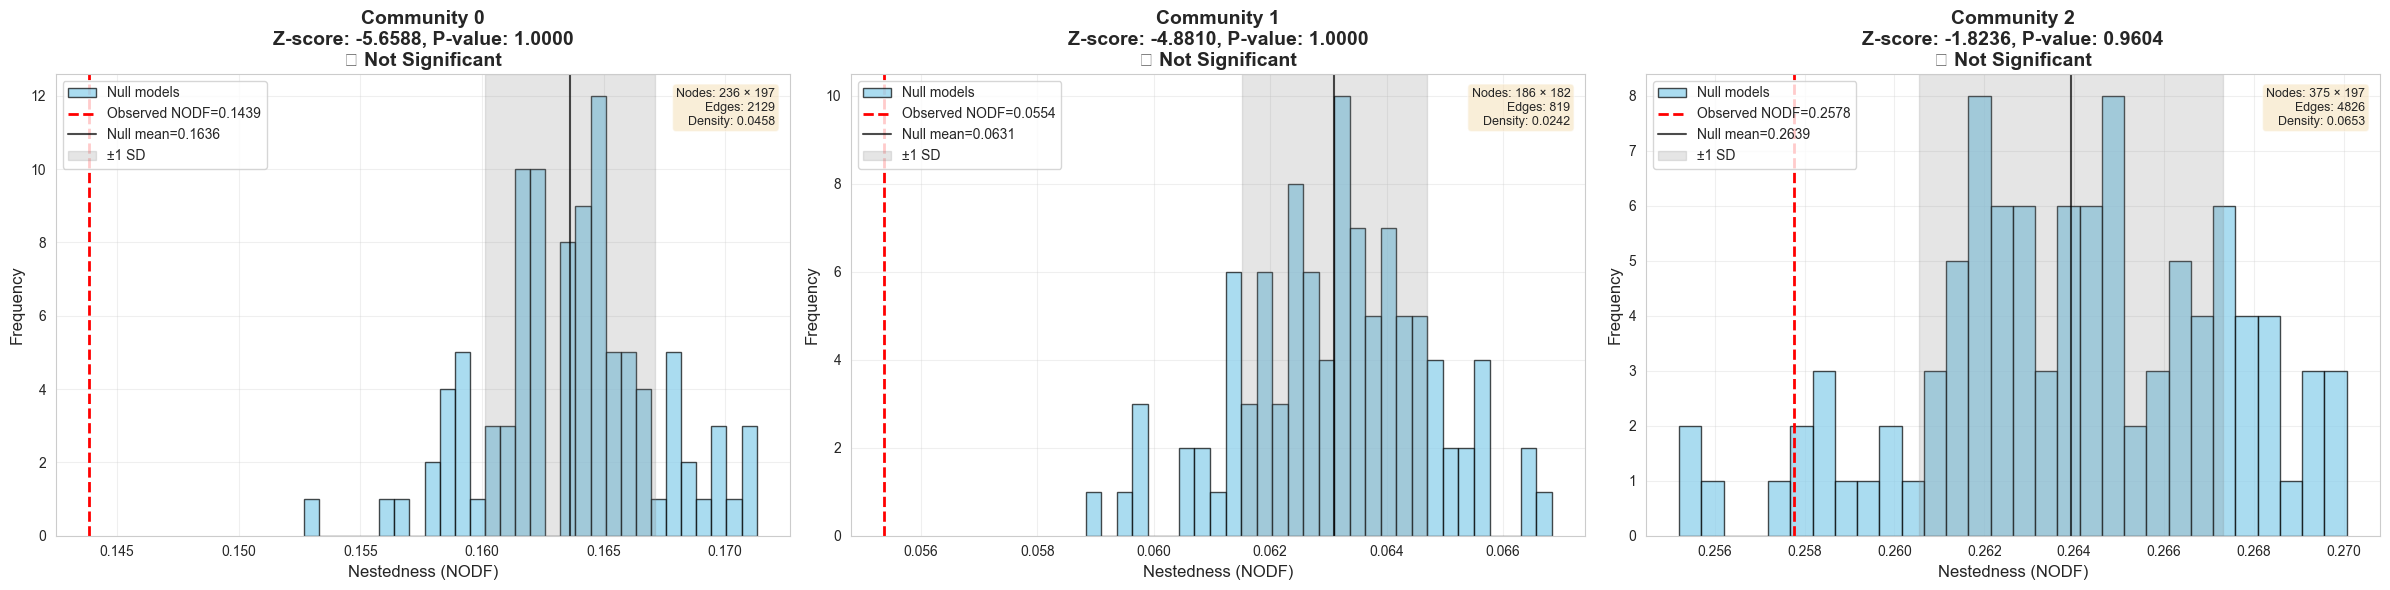

In [ ]:
# Plot all nestedness results together for Degree-Ratio strategy
plot_nestedness_null_distribution(
    nestedness_results_degree_ratio,
    save_path='../../reports/figures/us/nestedness_degree_ratio_communities_0_1_2.png'
)

In [53]:
Erro

NameError: name 'Erro' is not defined

In [ ]:
# Create summary table for Degree-Ratio strategy
if len(nestedness_results_degree_ratio) > 0:
    summary_data_dr = []
    for result in nestedness_results_degree_ratio:
        summary_data_dr.append({
            'Community': result['label'],
            'Left Nodes': result['left_nodes'],
            'Right Nodes': result['right_nodes'],
            'Edges': result['num_edges'],
            'Density': result['density'],
            'Observed NODF': result['observed_nodf'],
            'Null Mean': result['null_mean'],
            'Null Std': result['null_std'],
            'Z-score': result['z_score'],
            'P-value': result['p_value'],
            'Significant': 'Yes' if result['p_value'] < 0.05 else 'No'
        })
    
    summary_df_dr = pd.DataFrame(summary_data_dr)
    print("\n" + "="*80)
    print("NESTEDNESS SUMMARY TABLE - DEGREE-RATIO FILTERING")
    print("="*80)
    print(summary_df_dr.to_string(index=False))
    print("\n" + "="*80)

### Compare Nestedness Between Strategies

Compare the nestedness results from Strategy 1 (Generalist-Specialist) and Strategy 2 (Degree-Ratio).

In [ ]:
# Create comparison visualization
if len(nestedness_results_all) > 0 and len(nestedness_results_degree_ratio) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Comparison of Nestedness Between Filtering Strategies', 
                 fontsize=16, fontweight='bold')
    
    # Extract data for plotting
    communities = [0, 1, 2]
    strategy1_nodf = [r['observed_nodf'] for r in nestedness_results_all]
    strategy1_z = [r['z_score'] for r in nestedness_results_all]
    strategy2_nodf = [r['observed_nodf'] for r in nestedness_results_degree_ratio]
    strategy2_z = [r['z_score'] for r in nestedness_results_degree_ratio]
    
    # Plot 1: Observed NODF comparison
    ax1 = axes[0]
    x = np.arange(len(communities))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, strategy1_nodf, width, 
                    label='Generalist-Specialist', color='steelblue', alpha=0.8)
    bars2 = ax1.bar(x + width/2, strategy2_nodf, width, 
                    label='Degree-Ratio', color='orange', alpha=0.8)
    
    ax1.set_xlabel('Community', fontsize=12)
    ax1.set_ylabel('Observed NODF', fontsize=12)
    ax1.set_title('Observed Nestedness by Strategy', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Community {c}' for c in communities])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Z-score comparison
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, strategy1_z, width, 
                    label='Generalist-Specialist', color='steelblue', alpha=0.8)
    bars4 = ax2.bar(x + width/2, strategy2_z, width, 
                    label='Degree-Ratio', color='orange', alpha=0.8)
    
    ax2.axhline(y=1.96, color='red', linestyle='--', alpha=0.7, label='p=0.05 threshold')
    ax2.axhline(y=-1.96, color='red', linestyle='--', alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    ax2.set_xlabel('Community', fontsize=12)
    ax2.set_ylabel('Z-score', fontsize=12)
    ax2.set_title('Statistical Significance by Strategy', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Community {c}' for c in communities])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/us/nestedness_strategy_comparison.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print comparison summary
    print("\n" + "="*80)
    print("STRATEGY COMPARISON SUMMARY")
    print("="*80)
    for i, comm_id in enumerate(communities):
        print(f"\nCommunity {comm_id}:")
        print(f"  Generalist-Specialist: NODF={strategy1_nodf[i]:.4f}, Z={strategy1_z[i]:.4f}")
        print(f"  Degree-Ratio:          NODF={strategy2_nodf[i]:.4f}, Z={strategy2_z[i]:.4f}")
        diff_nodf = strategy1_nodf[i] - strategy2_nodf[i]
        diff_z = strategy1_z[i] - strategy2_z[i]
        print(f"  Difference:            ΔNODF={diff_nodf:.4f}, ΔZ={diff_z:.4f}")